# High Fidelity Neural Network
Neural Network which uses HF dataset and exploits the High fidelity component of the MF model  

In [35]:
#########################     LIBRARIES     ##########################
import keras.backend as K
from keras.regularizers import l2
from hyperopt import STATUS_OK, tpe, Trials, hp, fmin
from hyperopt.pyll.stochastic import sample
from sklearn.model_selection import KFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from keras.optimizers import Adam, Nadam, Adamax
from ann_functions2 import (
    getModel,
    kCrossVal,
    transfBestparam,
    kCrossValSingle,
    import_data, normalization
)
from time import perf_counter
import pandas
import os
import keras
import tensorflow as tf
seed = 7
np.random.seed(seed)

In [36]:
# reproducibility
seed = 42
np.random.seed(seed)
keras.utils.set_random_seed(seed)
tf.random.set_seed(seed)

# Data preparation

In [37]:
file_path_HF = "../DATA/reaction_diffusion_HF.mat"
(reaction_HF_test, U_HF_test) = import_data(file_path_HF)

NepoHF = 2000  # number of epochs for second NN: NN_HF

reaction_HF_test = normalization(reaction_HF_test)
reaction_HF_test=np.c_[reaction_HF_test, np.abs(np.sin(5*np.pi*reaction_HF_test[:, 0]-5*np.pi/6))]

permutation = np.random.permutation(len(reaction_HF_test))
Nhf = 20
reaction_HF = reaction_HF_test[permutation,:][0:Nhf,:]

In [38]:
U_HF_test = U_HF_test[:, -1, 44,44]

U_HF_test = normalization(U_HF_test)
U_HF = U_HF_test[permutation][0:Nhf]

# Neural Network

In [39]:
start = perf_counter()

#reaction_final = np.vstack(
#    (reaction_HF)
#) 

name = "HF"  # I leave the same NN,  even if we use HF data instead of LF
K.clear_session()
best_params = {
                    "kernel_init": "uniform",
                    "l2weight": 0.0002588943618918075,
                    "lr": 0.008365144388542751,
                    "nodes": 16.0,
                    "opt": "Adam",
                }
                

print(best_params)


{'kernel_init': 'uniform', 'l2weight': 0.0002588943618918075, 'lr': 0.008365144388542751, 'nodes': 16.0, 'opt': 'Adam'}


In [40]:
####################    NN training and PREDICTION    #######################
start2 = perf_counter()

finalModel = getModel(
    best_params, name
)  # final model chosen according to the best paramters
hist = finalModel.fit(
    reaction_HF,
    U_HF,
    validation_data=(reaction_HF_test, U_HF_test),
    epochs=NepoHF,
    batch_size=Nhf,
    verbose=0,
    validation_freq=20,
)

UHF = finalModel.predict(reaction_HF_test)

stop = perf_counter()
elapsed = stop - start
print("Elapsed time: ", elapsed)
print("\nHF Model:")

elapsed2 = stop - start2
print("Elapsed time: ", elapsed2)
print("\nHF Model:")
test_mse = np.mean(np.square(U_HF_test - UHF[:, 0]))
print(f"Test MSE: {test_mse}")

r2_HF = 1 - np.sum(np.square(U_HF_test - UHF[:, 0])) / np.sum(
    np.square(U_HF_test - np.mean(U_HF_test))
)
print(f"R^2: {r2_HF}")

2/2 [==============================] - 0s 4ms/step
Elapsed time:  16.555849199998192

HF Model:
Elapsed time:  16.38786309992429

HF Model:
Test MSE: 0.11541661793181783
R^2: -0.01959235602804843


# POST PROCESSING

2/2 [==============================] - 0s 4ms/step


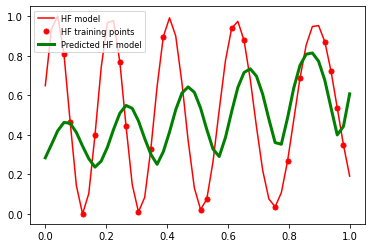

In [43]:
##################     Print LF, HF and LF-predicted models      ###################
plt.figure()
plt.plot(reaction_HF_test[:,0], U_HF_test, "r-", linewidth=1.5, label="HF model")
plt.plot(reaction_HF[:,0], U_HF, "ro", markersize=5, label="HF training points")
plt.plot(
    reaction_HF_test[:,0],
    finalModel.predict(reaction_HF_test),
    "g-",
    linewidth=3,
    label="Predicted HF model",
)
plt.legend(prop={"size": 8.3})
plt.show()

In [42]:
########################     SAVE the OUTPUT      ##########################

os.makedirs("NNHF_HF_20_2000_2")

R2_HF = pandas.DataFrame({"R2_HF": [r2_HF]})
MSE_test_HF = pandas.DataFrame({"MSE_test_HF": [test_mse]})


# R2_LF.to_csv('./Output_NNHF/r2_HF.txt', header=True, index=False, sep='\t', mode='a')
MSE_test_HF.to_csv(
    "./NNHF_HF_20_2000_2/test_mse.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
R2_HF.to_csv(
    "./NNHF_HF_20_2000_2/r2_LF_lhs.txt",
    header=True,
    index=False,
    sep="\t",
    mode="a",
)
